# Notebook 16: Logistic Regression Feature Importance Analysis

Load data and extract LR coefficients across LOYOCV folds.

Pearson checks straight line relationships between variables.

Spearman checks ranked relationships and works when the data is not normal.

Compute feature-outcome correlations and compare with permutation importance from Notebook 14.

Export results to Excel and save charts.

Results will be saved to: C:\Users\Nikita Danvill\OneDrive - University of Otago\Documents\INFO501\Nikita_Danvill_8887029_JupyterNotebooks_INFO501\Results
NOTEBOOK 16: LOGISTIC REGRESSION FEATURE IMPORTANCE ANALYSIS

STEP 1: Loading remediated features...
Features loaded: 21 total
Outcome distribution: Pass=887, Fail=267

STEP 2: Extracting LR coefficients across LOYOCV folds...

  Test year: 2014
    Best C: 0.1
  Test year: 2015
    Best C: 0.1
  Test year: 2016
    Best C: 0.01
  Test year: 2017
    Best C: 0.01
  Test year: 2018
    Best C: 0.1

STEP 3: Computing feature importance statistics...

Top 10 features by mean absolute coefficient:
                           Mean_Coefficient  Std_Coefficient  Mean_AbsCoef  Std_AbsCoef
levels_completed_3w                0.439953         0.129639      0.439953     0.129639
num_atmp_l3                        0.321375         0.043301      0.321375     0.043301
wk_comp_l2                         0.284134         0.038758      0.284134     0.0

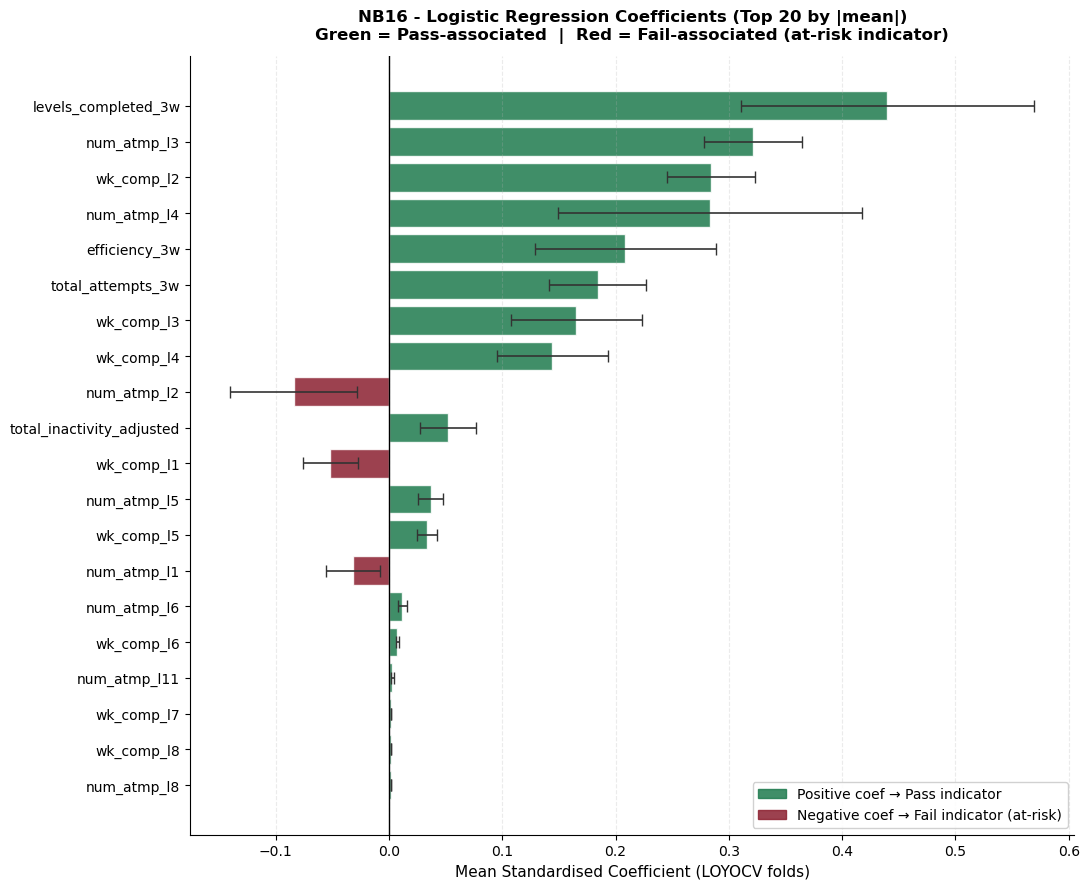

  ✓ Chart 1: LR coefficients bar chart saved


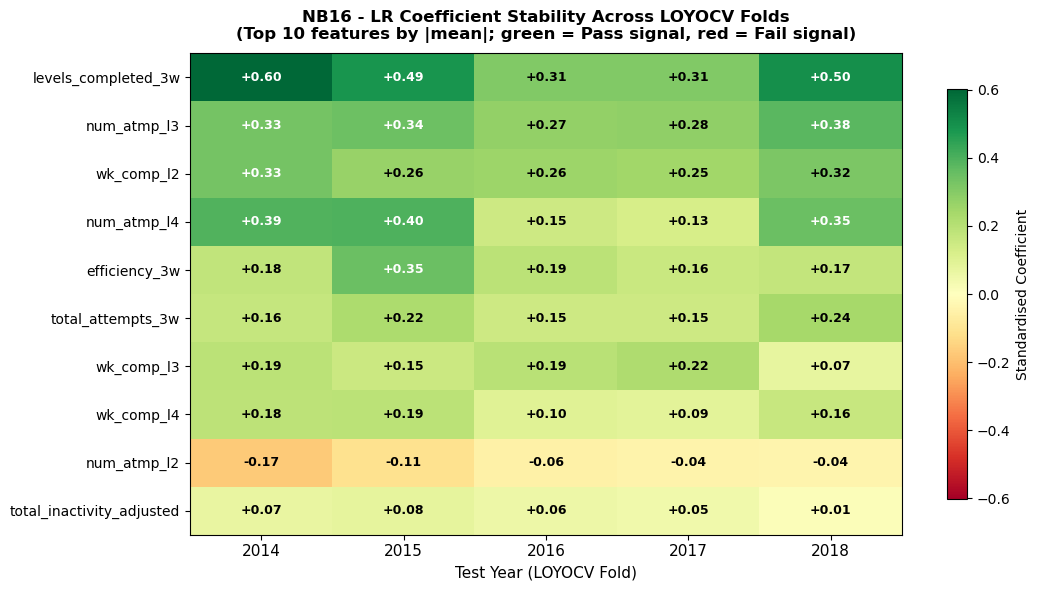

  ✓ Chart 2: Coefficient stability heatmap saved


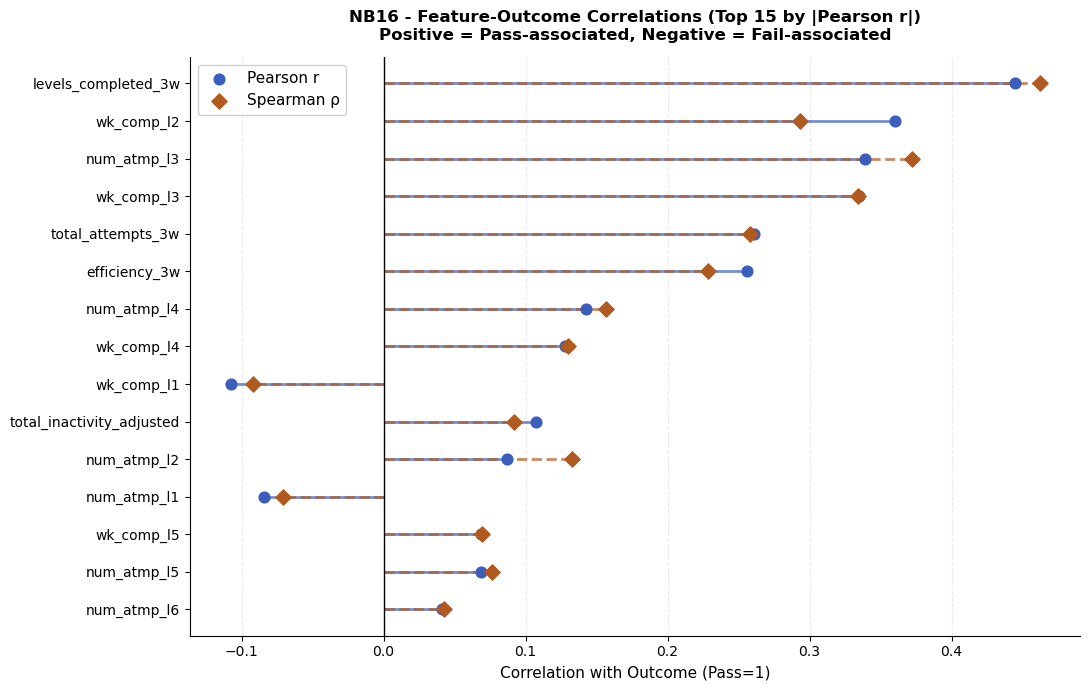

  ✓ Chart 3: Feature-outcome correlations lollipop saved

All NB16 visualizations saved to Results4 folder.

Top 10 Features by Mean Absolute LR Coefficient:


,Mean_Coefficient,Std_Coefficient,Mean_AbsCoef,Std_AbsCoef
levels_completed_3w,0.4400,0.1296,0.4400,0.1296
num_atmp_l3,0.3214,0.0433,0.3214,0.0433
wk_comp_l2,0.2841,0.0388,0.2841,0.0388
num_atmp_l4,0.2832,0.1343,0.2832,0.1343
efficiency_3w,0.2086,0.0799,0.2086,0.0799
total_attempts_3w,0.1842,0.0429,0.1842,0.0429
wk_comp_l3,0.1654,0.0578,0.1654,0.0578
wk_comp_l4,0.1441,0.0487,0.1441,0.0487
num_atmp_l2,-0.0841,0.0561,0.0841,0.0561
total_inactivity_adjusted,0.0518,0.0245,0.0518,0.0245



Top 10 Features by Pearson Correlation with Outcome:


,Pearson_Corr,Spearman_Corr,Abs_Pearson
levels_completed_3w,0.4447,0.4620,0.4447
wk_comp_l2,0.3603,0.2930,0.3603
num_atmp_l3,0.3391,0.3718,0.3391
wk_comp_l3,0.3348,0.3339,0.3348
total_attempts_3w,0.2610,0.2582,0.2610
efficiency_3w,0.2557,0.2284,0.2557
num_atmp_l4,0.1425,0.1566,0.1425
wk_comp_l4,0.1282,0.1296,0.1282
wk_comp_l1,-0.1077,-0.0922,0.1077
total_inactivity_adjusted,0.1077,0.0922,0.1077



NOTEBOOK 16 COMPLETE


In [1]:
# ──────────────────────────────────────────────────────────────────────────────
# NOTEBOOK 16: LOGISTIC REGRESSION FEATURE IMPORTANCE ANALYSIS
# ──────────────────────────────────────────────────────────────────────────────


import os
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, recall_score, balanced_accuracy_score

from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from openpyxl.utils.dataframe import dataframe_to_rows

def df_to_ws(ws, df, index=True, startrow=0):
    """Write a DataFrame to an openpyxl worksheet starting at startrow (0-indexed).
    index=True includes the DataFrame index as first column."""
    for r_idx, row in enumerate(dataframe_to_rows(df, index=index, header=True),
                                start=startrow + 1):
        for c_idx, value in enumerate(row, start=1):
            ws.cell(row=r_idx, column=c_idx, value=value)
    # Bold the header row
    for cell in ws[startrow + 1]:
        cell.font = Font(bold=True)

import warnings
warnings.filterwarnings('ignore')

# ──────────────────────────────────────────────────────────────────────────────
# CONFIGURATION
# ──────────────────────────────────────────────────────────────────────────────
RESULTS_DIR = os.path.join(os.getcwd(), "Results")
CHARTS_DIR  = os.path.join(os.getcwd(), "Charts")
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(CHARTS_DIR,  exist_ok=True)

print(f"Results will be saved to: {RESULTS_DIR}")
print("="*80)
print("NOTEBOOK 16: LOGISTIC REGRESSION FEATURE IMPORTANCE ANALYSIS")
print("="*80)

# Custom scorer for hyperparameter tuning
recall_fail_scorer = make_scorer(recall_score, pos_label=0)

# Parameter grid (same as NB13_v2)
param_grid = {'C': [0.01, 0.1, 1.0, 10.0, 100.0]}

test_years = [2014, 2015, 2016, 2017, 2018]

# ──────────────────────────────────────────────────────────────────────────────
# STEP 1: LOAD DATA
# ──────────────────────────────────────────────────────────────────────────────
print("\nSTEP 1: Loading remediated features...")

modeling_data = pd.read_excel("modeling_dataset.xlsx")
y = modeling_data["outcome"]
year_col = modeling_data["year"].copy()

X_remediated = pd.read_csv(os.path.join(RESULTS_DIR, "features_after_zero_ambiguity_fix.csv"))
feature_cols = [c for c in X_remediated.columns if c not in ['last_completion_week', 'trailing_gap_weeks']]
X_model = X_remediated[feature_cols].copy()

print(f"Features loaded: {len(feature_cols)} total")
print(f"Outcome distribution: Pass={sum(y==1)}, Fail={sum(y==0)}")

# ──────────────────────────────────────────────────────────────────────────────
# STEP 2: EXTRACT LR COEFFICIENTS ACROSS FOLDS
# ──────────────────────────────────────────────────────────────────────────────
print("\nSTEP 2: Extracting LR coefficients across LOYOCV folds...\n")

coefficients_by_fold = {}
coef_abs_by_fold = {}  # Absolute values for importance ranking

for test_year in test_years:
    print(f"  Test year: {int(test_year)}")
    
    train_mask = year_col != test_year
    X_train = X_model.loc[train_mask].copy()
    y_train = y.loc[train_mask].copy()
    
    # Standardize (required for LR coefficient interpretation)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    
    # Hyperparameter tuning
    lr_grid = GridSearchCV(
        LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
        param_grid, cv=3, scoring=recall_fail_scorer, n_jobs=-1
    )
    lr_grid.fit(X_train_scaled, y_train)
    
    # Refit final model on full training set with best params
    lr_final = LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42,
        **lr_grid.best_params_
    )
    lr_final.fit(X_train_scaled, y_train)
    
    # Extract coefficients
    coefs = lr_final.coef_[0]
    coefficients_by_fold[test_year] = coefs
    coef_abs_by_fold[test_year] = np.abs(coefs)
    
    print(f"    Best C: {lr_grid.best_params_['C']}")

# ──────────────────────────────────────────────────────────────────────────────
# STEP 3: COMPUTE FEATURE IMPORTANCE STATISTICS
# ──────────────────────────────────────────────────────────────────────────────
print("\nSTEP 3: Computing feature importance statistics...\n")

coef_df = pd.DataFrame(coefficients_by_fold, index=feature_cols).T
coef_abs_df = pd.DataFrame(coef_abs_by_fold, index=feature_cols).T

# Summary statistics
coef_summary = pd.DataFrame({
    'Mean_Coefficient': coef_df.mean(),
    'Std_Coefficient': coef_df.std(),
    'Mean_AbsCoef': coef_abs_df.mean(),
    'Std_AbsCoef': coef_abs_df.std()
}).sort_values('Mean_AbsCoef', ascending=False)

print("Top 10 features by mean absolute coefficient:")
print(coef_summary.head(10).to_string())

# ──────────────────────────────────────────────────────────────────────────────
# STEP 4: COMPUTE CORRELATIONS (Pearson & Spearman)
# ──────────────────────────────────────────────────────────────────────────────
print("\nSTEP 4: Computing feature-outcome correlations...\n")

pearson_corr = []
spearman_corr = []

for col in feature_cols:
    pc, _ = pearsonr(X_model[col], y)
    sc, _ = spearmanr(X_model[col], y)
    pearson_corr.append(pc)
    spearman_corr.append(sc)

correlation_df = pd.DataFrame({
    'Pearson_Corr': pearson_corr,
    'Spearman_Corr': spearman_corr,
    'Abs_Pearson': np.abs(pearson_corr),
    'Abs_Spearman': np.abs(spearman_corr)
}, index=feature_cols).sort_values('Abs_Pearson', ascending=False)

print("Top 10 features by Pearson correlation:")
print(correlation_df[['Pearson_Corr', 'Spearman_Corr']].head(10).to_string())

# ──────────────────────────────────────────────────────────────────────────────
# STEP 5: COMPARISON WITH PERMUTATION IMPORTANCE (from NB14)
# ──────────────────────────────────────────────────────────────────────────────
print("\nSTEP 5: Comparing with permutation importance (if available)...\n")

# Try to load permutation importance from NB14
perm_importance_file = os.path.join(RESULTS_DIR, "Notebook_14_Feature_Importance_Selection.xlsx")

if os.path.exists(perm_importance_file):
    try:
        perm_df = pd.read_excel(perm_importance_file, sheet_name='Logistic Regression', index_col=0)
        print("✓ Loaded permutation importance from NB14")
        print(f"  Permutation importance shape: {perm_df.shape}")
        
        # Compare rankings
        coef_rank = coef_summary['Mean_AbsCoef'].rank(ascending=False)
        perm_rank = perm_df['Mean Importance'].rank(ascending=False)
        
        comparison = pd.DataFrame({
            'LR_Coefficient_Rank': coef_rank,
            'Permutation_Importance_Rank': perm_rank,
            'Rank_Difference': (coef_rank - perm_rank).abs()
        }).sort_values('Rank_Difference', ascending=False)
        
        print("\nTop 10 features with most different rankings:")
        print(comparison.head(10).to_string())
    except Exception as e:
        print(f"⚠ Could not load permutation importance: {e}")
        perm_df = None
else:
    print(f"⚠ Permutation importance file not found: {perm_importance_file}")
    perm_df = None

# ──────────────────────────────────────────────────────────────────────────────
# STEP 6: EXPORT RESULTS TO EXCEL
# ──────────────────────────────────────────────────────────────────────────────
print("\nSTEP 6: Exporting results to Excel...")

output_file = os.path.join(RESULTS_DIR, "Notebook_16_LR_Feature_Importance.xlsx")
wb = Workbook()

# Sheet 1: LR Coefficients per fold
ws1 = wb.active
ws1.title = "LR Coefficients by Fold"
df_to_ws(ws1, coef_df, index=True, startrow=0)

# Sheet 2: Summary statistics
ws2 = wb.create_sheet("Coefficient Summary")
df_to_ws(ws2, coef_summary, index=True, startrow=0)

# Sheet 3: Correlations
ws3 = wb.create_sheet("Feature Correlations")
df_to_ws(ws3, correlation_df, index=True, startrow=0)

# Sheet 4: Combined ranking
ws4 = wb.create_sheet("Combined Importance")
combined = pd.DataFrame({
    'LR_Mean_AbsCoef': coef_summary['Mean_AbsCoef'],
    'LR_Coefficient_Rank': coef_summary['Mean_AbsCoef'].rank(ascending=False),
    'Pearson_Correlation': correlation_df['Pearson_Corr'],
    'Abs_Pearson_Rank': correlation_df['Abs_Pearson'].rank(ascending=False),
    'Spearman_Correlation': correlation_df['Spearman_Corr'],
    'Abs_Spearman_Rank': correlation_df['Abs_Spearman'].rank(ascending=False)
}).sort_values('LR_Coefficient_Rank')
df_to_ws(ws4, combined, index=True, startrow=0)

# Sheet 5: Comparison with permutation (if available)
if perm_df is not None:
    ws5 = wb.create_sheet("LR vs Permutation")
    df_to_ws(ws5, comparison, index=True, startrow=0)

# Sheet 6: Analysis summary
ws6 = wb.create_sheet("Analysis Summary")
summary_text = [
    ["Logistic Regression Feature Importance Analysis", ""],
    ["", ""],
    ["Interpretation Guide:", ""],
    ["LR Coefficient", "Strength of linear relationship with outcome (after standardization)"],
    ["Positive coefficient", "Associated with higher probability of PASS"],
    ["Negative coefficient", "Associated with higher probability of FAIL (at-risk indicator)"],
    ["", ""],
    ["Pearson Correlation", "Linear correlation with outcome (range: -1 to 1)"],
    ["Spearman Correlation", "Rank-based correlation (non-linear relationships)"],
    ["", ""],
    ["Key Findings:", ""],
    [f"Total features analyzed: {len(feature_cols)}", ""],
    [f"Test years (LOYOCV folds): {test_years}", ""],
    [f"Top feature (by LR coefficient): {coef_summary.index[0]}", ""],
    [f"Std dev of top feature across folds: {coef_summary.iloc[0]['Std_Coefficient']:.4f}", ""],
]

for i, row in enumerate(summary_text, 1):
    for j, val in enumerate(row, 1):
        ws6.cell(row=i, column=j, value=val)

wb.save(output_file)
print(f"✓ Saved: {output_file}")

# ──────────────────────────────────────────────────────────────────────────────
# STEP 7: INSIGHTS
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "="*80)
print("KEY INSIGHTS FROM LR FEATURE IMPORTANCE ANALYSIS")
print("="*80)

print(f"\n1. MOST IMPORTANT FEATURES (by mean absolute coefficient):")
for i, (feat, row) in enumerate(coef_summary.head(5).iterrows(), 1):
    print(f"   {i}. {feat:30s} | Mean|Coef|={row['Mean_AbsCoef']:.4f} ± {row['Std_AbsCoef']:.4f}")

print(f"\n2. LEAST IMPORTANT FEATURES (by mean absolute coefficient):")
for i, (feat, row) in enumerate(coef_summary.tail(5).iterrows(), 1):
    print(f"   {i}. {feat:30s} | Mean|Coef|={row['Mean_AbsCoef']:.4f} ± {row['Std_AbsCoef']:.4f}")

print(f"\n3. STRONGEST CORRELATIONS WITH OUTCOME:")
for i, (feat, row) in enumerate(correlation_df[['Pearson_Corr']].head(5).iterrows(), 1):
    corr_val = row['Pearson_Corr']
    direction = "Pass" if corr_val > 0 else "Fail"
    print(f"   {i}. {feat:30s} | r = {corr_val:+.4f} → {direction}")

print(f"\n4. COEFFICIENT STABILITY ACROSS FOLDS:")
stability = coef_summary['Std_Coefficient'] / (coef_summary['Mean_Coefficient'].abs() + 1e-6)
stable_feats = stability[stability < 0.5].index.tolist()
unstable_feats = stability[stability > 1.0].index.tolist()
print(f"   Stable features (low variability): {len(stable_feats)}")
if stable_feats:
    print(f"     Examples: {', '.join(stable_feats[:3])}")
print(f"   Unstable features (high variability): {len(unstable_feats)}")
if unstable_feats:
    print(f"     Examples: {', '.join(unstable_feats[:3])}")


# ══════════════════════════════════════════════════════════════════════════════
# STEP 7b: VISUALIZATIONS
# ══════════════════════════════════════════════════════════════════════════════
print("\nSTEP 7b: Generating visualizations...")
import numpy as np

try:
    from IPython.display import display as ipy_display
except ImportError:
    ipy_display = lambda x: None

# ── CHART 1: Mean LR Coefficients - horizontal bar chart ─────────────────────
fig, ax = plt.subplots(figsize=(11, 9))

top20         = coef_summary.head(20).copy()
feat_names    = top20.index.tolist()
mean_coefs    = top20['Mean_Coefficient'].values
std_coefs     = top20['Std_Coefficient'].values

# Colour by direction: positive coef = Pass-associated, negative = Fail-associated
bar_colors = ['#1E7A4E' if v >= 0 else '#8B2030' for v in mean_coefs]

y_pos = np.arange(len(feat_names))[::-1]
bars  = ax.barh(y_pos, mean_coefs, xerr=std_coefs, capsize=4,
                color=bar_colors, alpha=0.85, edgecolor='white',
                error_kw={'elinewidth': 1.2, 'ecolor': '#333333'})
ax.axvline(0, color='black', linewidth=1.0)
ax.set_yticks(y_pos)
ax.set_yticklabels(feat_names, fontsize=10)
ax.set_xlabel('Mean Standardised Coefficient (LOYOCV folds)', fontsize=11)
ax.set_title('NB16 - Logistic Regression Coefficients (Top 20 by |mean|)\n'
             'Green = Pass-associated  |  Red = Fail-associated (at-risk indicator)',
             fontsize=12, fontweight='bold', pad=12)
ax.grid(axis='x', alpha=0.25, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

import matplotlib.patches as mpatches
pass_patch = mpatches.Patch(color='#1E7A4E', alpha=0.85, label='Positive coef → Pass indicator')
fail_patch = mpatches.Patch(color='#8B2030', alpha=0.85, label='Negative coef → Fail indicator (at-risk)')
ax.legend(handles=[pass_patch, fail_patch], loc='lower right', fontsize=10, framealpha=0.9)
fig.tight_layout()
fig.savefig(os.path.join(CHARTS_DIR, 'NB16_lr_coefficients.png'), dpi=150, bbox_inches='tight')
ipy_display(fig)
plt.close(fig)
print("  ✓ Chart 1: LR coefficients bar chart saved")

# ── CHART 2: Coefficient heatmap across LOYOCV folds ────────────────────────
top10_feats = coef_summary.head(10).index.tolist()
heat_data   = coef_df[top10_feats].T.values   # shape: (10 features, 5 folds)

fig, ax = plt.subplots(figsize=(11, 6))
vmax    = np.abs(heat_data).max()
im      = ax.imshow(heat_data, cmap='RdYlGn', vmin=-vmax, vmax=vmax, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.85, label='Standardised Coefficient')
ax.set_xticks(range(len(test_years)))
ax.set_xticklabels([str(y) for y in test_years], fontsize=11)
ax.set_yticks(range(len(top10_feats)))
ax.set_yticklabels(top10_feats, fontsize=10)
ax.set_xlabel('Test Year (LOYOCV Fold)', fontsize=11)
ax.set_title('NB16 - LR Coefficient Stability Across LOYOCV Folds\n'
             '(Top 10 features by |mean|; green = Pass signal, red = Fail signal)',
             fontsize=12, fontweight='bold', pad=10)
for r in range(len(top10_feats)):
    for c in range(len(test_years)):
        val   = heat_data[r, c]
        color = 'white' if abs(val) > vmax * 0.55 else 'black'
        sign  = '+' if val >= 0 else ''
        ax.text(c, r, f'{sign}{val:.2f}', ha='center', va='center',
                fontsize=9, fontweight='bold', color=color)
fig.tight_layout()
fig.savefig(os.path.join(CHARTS_DIR, 'NB16_coefficient_heatmap.png'), dpi=150, bbox_inches='tight')
ipy_display(fig)
plt.close(fig)
print("  ✓ Chart 2: Coefficient stability heatmap saved")

# ── CHART 3: Pearson vs Spearman correlation lollipop chart ─────────────────
top15_corr = correlation_df.head(15).copy()
feat_corr  = top15_corr.index.tolist()
pearson_r  = top15_corr['Pearson_Corr'].values
spearman_r = top15_corr['Spearman_Corr'].values

fig, ax = plt.subplots(figsize=(11, 7))
y_pos   = np.arange(len(feat_corr))[::-1]
ax.hlines(y_pos, 0, pearson_r,   colors='#3B5EBD', linewidth=2, alpha=0.7)
ax.hlines(y_pos, 0, spearman_r,  colors='#B05A20', linewidth=2, alpha=0.7, linestyle='--')
ax.scatter(pearson_r,  y_pos, color='#3B5EBD', s=60, zorder=5, label='Pearson r')
ax.scatter(spearman_r, y_pos, color='#B05A20', s=60, zorder=5, label='Spearman ρ', marker='D')
ax.axvline(0, color='black', linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(feat_corr, fontsize=10)
ax.set_xlabel('Correlation with Outcome (Pass=1)', fontsize=11)
ax.set_title('NB16 - Feature-Outcome Correlations (Top 15 by |Pearson r|)\n'
             'Positive = Pass-associated, Negative = Fail-associated',
             fontsize=12, fontweight='bold', pad=12)
ax.legend(fontsize=11, framealpha=0.92)
ax.grid(axis='x', alpha=0.25, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.tight_layout()
fig.savefig(os.path.join(CHARTS_DIR, 'NB16_correlations.png'), dpi=150, bbox_inches='tight')
ipy_display(fig)
plt.close(fig)
print("  ✓ Chart 3: Feature-outcome correlations lollipop saved")
print("\nAll NB16 visualizations saved to Results4 folder.")

# ── Display key results in Jupyter output ────────────────────────────────────
try:
    from IPython.display import display as ipy_display
    print("\nTop 10 Features by Mean Absolute LR Coefficient:")
    ipy_display(coef_summary.head(10).style
        .set_caption("NB16 - LR Coefficient Summary (top 10)")
        .set_table_styles([{'selector': 'th', 'props': [('background-color','#1A3A5C'),('color','white')]}])
        .background_gradient(cmap='YlOrRd', subset=['Mean_AbsCoef'])
        .format({'Mean_Coefficient':'{:.4f}','Std_Coefficient':'{:.4f}',
                 'Mean_AbsCoef':'{:.4f}','Std_AbsCoef':'{:.4f}'}))
    print("\nTop 10 Features by Pearson Correlation with Outcome:")
    ipy_display(correlation_df[['Pearson_Corr','Spearman_Corr','Abs_Pearson']].head(10).style
        .set_caption("NB16 - Feature-Outcome Correlations (top 10)")
        .set_table_styles([{'selector': 'th', 'props': [('background-color','#1A3A5C'),('color','white')]}])
        .background_gradient(cmap='RdYlGn', subset=['Pearson_Corr'])
        .format('{:.4f}'))
except Exception as _e:
    print(f"(Display not available: {_e})")
    print(coef_summary.head(10).to_string())

print("\n" + "="*80)
print("NOTEBOOK 16 COMPLETE")
print("="*80)


# References

- Scikit-learn Documentation: https://scikit-learn.org/stable/
- Grid Search: https://scikit-learn.org/stable/modules/grid_search.html
- Logistic Regression: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
- Pearson Correlation: https://statistics.laerd.com/statistical-guides/pearson-correlation-coefficient-statistical-guide.php
- Spearman Correlation: https://statistics.laerd.com/statistical-guides/spearmans-rank-order-correlation-statistical-guide.php